In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Projects_AI_DS/bearing_fault/IMS.zip"
extract_path = "/content/mydata"

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:", os.listdir(extract_path))


Extracted files: ['IMS', '__MACOSX']


In [ ]:
!apt-get install unrar
!unrar x /content/mydata/IMS/1st_test.rar /content/mydata/IMS/
# !unrar x /content/mydata/IMS/2nd_test.rar /content/mydata/IMS/
# !unrar x /content/mydata/IMS/3rd_test.rar /content/mydata/IMS/

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/mydata/IMS/1st_test.rar

Creating    /content/mydata/IMS/1st_test                              OK
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.06.24               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.09.13               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.14.13               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.19.13               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.24.13               0%  OK 
Extracting  /content/mydata/IMS/1st_test/2003.10.22.12.29.13               0%  OK 
Extracting  /content/mydata/IMS

file_level

In [ ]:
# ================= FAST IMS BEARING FAULT DETECTION =================
# ================= WINDOW = 1024 | STRIDE = 512 =================
# ================= LEAKAGE-FREE EVALUATION =================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1200

# -------------------------------------------------------
# FAST WINDOWING
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FAST FEATURE EXTRACTION
# -------------------------------------------------------

def extract_features(w):

    # w shape -> (N, 1024, 2)

    w = w.astype(np.float32)

    # ---------- RMS ----------
    rms = np.sqrt(np.mean(w * w, axis=1))

    # ---------- STD ----------
    std = np.std(w, axis=1)

    # ---------- PEAK ----------
    peak = np.max(np.abs(w), axis=1)

    # ---------- PEAK TO RMS ----------
    pr = peak / (rms + 1e-8)

    # ---------- TREND ----------
    t = np.arange(rms.shape[0], dtype=np.float32)

    t_mean = t.mean()
    t_var = np.sum((t - t_mean) ** 2) + 1e-8

    slopes = []

    for c in range(2):

        y = rms[:, c]

        y_mean = y.mean()

        slope = np.sum((t - t_mean) * (y - y_mean)) / t_var

        slopes.append(slope)

    # ---------- DAMAGE ----------
    damage = np.sum(np.abs(np.diff(rms.mean(axis=1))))

    # ---------- FINAL FEATURES ----------
    feats = np.concatenate([

        rms.mean(axis=0),
        rms.std(axis=0),

        std.mean(axis=0),
        std.std(axis=0),

        peak.mean(axis=0),
        peak.std(axis=0),

        pr.mean(axis=0),
        pr.std(axis=0),

        np.array(slopes),

        np.array([damage])

    ])

    return feats

# -------------------------------------------------------
# BUILD DATASET
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X = []
y = []
groups = []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4,5,6,7]
    ).values.astype(np.float32)

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    # ---------------- WINDOWING ----------------

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    # ---------------- FEATURES ----------------

    X.append(extract_features(w3))
    y.append(0 if i < HEALTHY_END else 1)
    groups.append(i)

    X.append(extract_features(w4))
    y.append(0 if i < HEALTHY_END else 2)
    groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)
print("Class Distribution:")
print(np.unique(y, return_counts=True))

# -------------------------------------------------------
# LEAKAGE-FREE EVALUATION
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups)
):

    print(f"\n========== Fold {fold+1} ==========")

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    # ---------------- SCALING ----------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ---------------- MODEL ----------------

    model = LGBMClassifier(
        n_estimators=100,      # reduced
        learning_rate=0.08,    # faster convergence
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,             # full CPU usage
        verbosity=-1
    )

    # ---------------- TRAIN ----------------

    model.fit(X_train, y_train)

    # ---------------- PREDICT ----------------

    preds = model.predict(X_test)

    all_preds.extend(preds)
    all_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULT
# -------------------------------------------------------

print("\n================ FINAL RESULT ================")
print("Leakage-Free Evaluation using GroupKFold\n")

print(classification_report(all_true, all_preds))

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (4312, 19)
Class Distribution:
(array([0, 1, 2]), array([2400,  956,  956]))

========== Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 2 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 3 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 4 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 5 ==========
Fold Completed

================ FINAL RESULT ================
Leakage-Free Evaluation using GroupKFold

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      2400
           1       0.76      0.80      0.78       956
           2       1.00      0.96      0.97       956

    accuracy                           0.89      4312
   macro avg       0.88      0.88      0.88      4312
weighted avg       0.89      0.89      0.89      4312



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


window_level

In [ ]:
# ================= FAST WINDOW-LEVEL IMS BEARING FAULT DETECTION =================
# ================= WINDOW = 1024 | STRIDE = 512 =================
# ================= LEAKAGE-FREE EVALUATION =================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1600

# -------------------------------------------------------
# WINDOWING (FAST)
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FEATURE EXTRACTION (IMPROVED FOR CLASS 1)
# -------------------------------------------------------

def extract_features(window):

    window = window.astype(np.float32)

    # ---------- basic stats ----------
    rms = np.sqrt(np.mean(window ** 2, axis=0))
    std = np.std(window, axis=0)
    peak = np.max(np.abs(window), axis=0)
    pr = peak / (rms + 1e-8)

    # ---------- trend ----------
    t = np.arange(window.shape[0], dtype=np.float32)

    slopes = []
    for c in range(window.shape[1]):
        y = window[:, c]
        slope = np.sum((t - t.mean()) * (y - y.mean())) / (np.sum((t - t.mean())**2) + 1e-8)
        slopes.append(slope)

    # ---------- IMPORTANT (class 1 improvement features) ----------

    # 1. signal roughness (early fault sensitivity)
    roughness = np.mean(np.diff(window, axis=0) ** 2)

    # 2. high frequency energy (inner race indicator)
    fft = np.abs(np.fft.rfft(window, axis=0))
    hf_energy = np.sum(fft[20:], axis=0).mean() / (np.sum(fft) + 1e-8)

    # ---------- damage ----------
    damage = np.sum(np.abs(np.diff(window.mean(axis=1))))

    return np.concatenate([
        rms,
        std,
        peak,
        pr,
        np.array(slopes),
        np.array([damage, roughness, hf_energy])
    ])

# -------------------------------------------------------
# BUILD DATASET (WINDOW LEVEL)
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X = []
y = []
groups = []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4, 5, 6, 7]
    ).values.astype(np.float32)

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    label_b3 = 0 if i < HEALTHY_END else 1
    label_b4 = 0 if i < HEALTHY_END else 2

    # -------- window-level append --------
    for w in w3:
        X.append(extract_features(w))
        y.append(label_b3)
        groups.append(i)

    for w in w4:
        X.append(extract_features(w))
        y.append(label_b4)
        groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)
print("Class Distribution:", np.unique(y, return_counts=True))

# -------------------------------------------------------
# LEAKAGE-FREE EVALUATION
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\n========== Fold {fold+1} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.08,
        num_leaves=31,
        class_weight={0:1, 1:3, 2:1},   # 🔥 improved class-1 focus
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    all_preds.extend(preds)
    all_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULT
# -------------------------------------------------------

print("\n================ FINAL RESULT ================")
print(classification_report(all_true, all_preds, digits=4))

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (168168, 13)
Class Distribution: (array([0, 1, 2]), array([124800,  21684,  21684]))

========== Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 2 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 3 ==========


...

Fold Completed

========== Fold 4 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 5 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

================ FINAL RESULT ================
              precision    recall  f1-score   support

           0     0.9576    0.9421    0.9498    124800
           1     0.7123    0.7919    0.7500     21684
           2     0.9801    0.9615    0.9707     21684

    accuracy                         0.9253    168168
   macro avg     0.8833    0.8985    0.8902    168168
weighted avg     0.9288    0.9253    0.9267    168168



In [ ]:
# ================= FAST WINDOW-LEVEL IMS BEARING FAULT DETECTION =================
# ================= WINDOW = 1024 | STRIDE = 512 =================
# ================= LEAKAGE-FREE EVALUATION =================

import os
import numpy as np
import pandas as pd

from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1600

# -------------------------------------------------------
# WINDOWING (FAST)
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FEATURE EXTRACTION (IMPROVED FOR CLASS 1)
# -------------------------------------------------------

def extract_features(window):

    window = window.astype(np.float32)

    # ---------- basic stats ----------
    rms = np.sqrt(np.mean(window ** 2, axis=0))
    std = np.std(window, axis=0)
    peak = np.max(np.abs(window), axis=0)
    pr = peak / (rms + 1e-8)

    # ---------- trend ----------
    t = np.arange(window.shape[0], dtype=np.float32)

    slopes = []

    for c in range(window.shape[1]):

        y = window[:, c]

        slope = np.sum((t - t.mean()) * (y - y.mean())) / (
            np.sum((t - t.mean())**2) + 1e-8
        )

        slopes.append(slope)

    # ---------- IMPORTANT FEATURES ----------

    # 1. signal roughness
    roughness = np.mean(np.diff(window, axis=0) ** 2)

    # 2. high frequency energy
    fft = np.abs(np.fft.rfft(window, axis=0))

    hf_energy = (
        np.sum(fft[20:], axis=0).mean()
        / (np.sum(fft) + 1e-8)
    )

    # 3. envelope energy
    env = np.abs(hilbert(window, axis=0))
    env_energy = np.mean(env ** 2)

    # 4. crest factor
    crest = np.mean(peak / (std + 1e-8))

    # ---------- damage ----------
    damage = np.sum(np.abs(np.diff(window.mean(axis=1))))

    # ---------- FINAL FEATURES ----------

    return np.concatenate([

        rms,
        std,
        peak,
        pr,

        np.array(slopes),

        np.array([
            damage,
            roughness,
            hf_energy,
            env_energy,
            crest
        ])

    ])

# -------------------------------------------------------
# BUILD DATASET (WINDOW LEVEL)
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X = []
y = []
groups = []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4, 5, 6, 7]
    ).values.astype(np.float32)

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    label_b3 = 0 if i < HEALTHY_END else 1
    label_b4 = 0 if i < HEALTHY_END else 2

    # -------- window-level append --------

    for w in w3:
        X.append(extract_features(w))
        y.append(label_b3)
        groups.append(i)

    for w in w4:
        X.append(extract_features(w))
        y.append(label_b4)
        groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)
print("Class Distribution:", np.unique(y, return_counts=True))

# -------------------------------------------------------
# LEAKAGE-FREE EVALUATION
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

all_preds = []
all_true = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\n========== Fold {fold+1} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.08,
        num_leaves=31,
        class_weight={0:1, 1:3, 2:1},
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    all_preds.extend(preds)
    all_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULT
# -------------------------------------------------------

print("\n================ FINAL RESULT ================")
print(classification_report(all_true, all_preds, digits=4))

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (168168, 15)
Class Distribution: (array([0, 1, 2]), array([124800,  21684,  21684]))

========== Fold 1 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 2 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 3 ==========


...

Fold Completed

========== Fold 4 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

========== Fold 5 ==========


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold Completed

================ FINAL RESULT ================
              precision    recall  f1-score   support

           0     0.9575    0.9416    0.9495    124800
           1     0.7107    0.7920    0.7491     21684
           2     0.9798    0.9616    0.9706     21684

    accuracy                         0.9249    168168
   macro avg     0.8827    0.8984    0.8898    168168
weighted avg     0.9286    0.9249    0.9264    168168



In [ ]:
# ================= WINDOW-LEVEL IMS PIPELINE =================
# ===== LGBM FEATURE SELECTION -> XGBOOST + RF ==============

import os
import numpy as np
import pandas as pd

from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1600

TOP_K = 10   # top important features

# -------------------------------------------------------
# WINDOWING
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FEATURE EXTRACTION
# -------------------------------------------------------

def extract_features(window):

    window = window.astype(np.float32)

    # ---------- basic stats ----------
    rms = np.sqrt(np.mean(window ** 2, axis=0))
    std = np.std(window, axis=0)
    peak = np.max(np.abs(window), axis=0)
    pr = peak / (rms + 1e-8)

    # ---------- trend ----------
    t = np.arange(window.shape[0], dtype=np.float32)

    slopes = []

    for c in range(window.shape[1]):

        y = window[:, c]

        slope = np.sum((t - t.mean()) * (y - y.mean())) / (
            np.sum((t - t.mean())**2) + 1e-8
        )

        slopes.append(slope)

    # ---------- extra features ----------

    roughness = np.mean(np.diff(window, axis=0) ** 2)

    fft = np.abs(np.fft.rfft(window, axis=0))

    hf_energy = (
        np.sum(fft[20:], axis=0).mean()
        / (np.sum(fft) + 1e-8)
    )

    env = np.abs(hilbert(window, axis=0))
    env_energy = np.mean(env ** 2)

    crest = np.mean(peak / (std + 1e-8))

    damage = np.sum(np.abs(np.diff(window.mean(axis=1))))

    return np.concatenate([

        rms,
        std,
        peak,
        pr,

        np.array(slopes),

        np.array([
            damage,
            roughness,
            hf_energy,
            env_energy,
            crest
        ])

    ])

# -------------------------------------------------------
# BUILD DATASET
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X = []
y = []
groups = []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4, 5, 6, 7]
    ).values.astype(np.float32)

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    label_b3 = 0 if i < HEALTHY_END else 1
    label_b4 = 0 if i < HEALTHY_END else 2

    for w in w3:
        X.append(extract_features(w))
        y.append(label_b3)
        groups.append(i)

    for w in w4:
        X.append(extract_features(w))
        y.append(label_b4)
        groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)
print("Class Distribution:", np.unique(y, return_counts=True))

# -------------------------------------------------------
# GROUP KFOLD
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

# =======================================================
# XGBOOST RESULTS
# =======================================================

xgb_preds = []
xgb_true = []

# =======================================================
# RF RESULTS
# =======================================================

rf_preds = []
rf_true = []

# -------------------------------------------------------
# CV LOOP
# -------------------------------------------------------

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\n========== Fold {fold+1} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # ---------------- SCALE ----------------

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ---------------------------------------------------
    # STAGE 1 -> LIGHTGBM FEATURE IMPORTANCE
    # ---------------------------------------------------

    selector_model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.08,
        num_leaves=31,
        class_weight={0:1, 1:3, 2:1},
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    selector_model.fit(X_train, y_train)

    importances = selector_model.feature_importances_

    top_idx = np.argsort(importances)[-TOP_K:]

    X_train_sel = X_train[:, top_idx]
    X_test_sel = X_test[:, top_idx]

    print("Selected Features:", top_idx)

    # ---------------------------------------------------
    # STAGE 2 -> XGBOOST
    # ---------------------------------------------------

    xgb_model = XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=3,
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )

    xgb_model.fit(X_train_sel, y_train)

    xgb_pred = xgb_model.predict(X_test_sel)

    xgb_preds.extend(xgb_pred)
    xgb_true.extend(y_test)

    # ---------------------------------------------------
    # STAGE 3 -> RANDOM FOREST
    # ---------------------------------------------------

    rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    rf_model.fit(X_train_sel, y_train)

    rf_pred = rf_model.predict(X_test_sel)

    rf_preds.extend(rf_pred)
    rf_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULTS
# -------------------------------------------------------

print("\n================ XGBOOST RESULT ================")
print(classification_report(xgb_true, xgb_preds, digits=4))

print("\n================ RANDOM FOREST RESULT ================")
print(classification_report(rf_true, rf_preds, digits=4))

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (168168, 15)
Class Distribution: (array([0, 1, 2]), array([124800,  21684,  21684]))

========== Fold 1 ==========
Selected Features: [ 6  4  1 14 12  2 13  3 10 11]
Fold Completed

========== Fold 2 ==========
Selected Features: [ 4  6  1 14 12  2 13  3 10 11]
Fold Completed

========== Fold 3 ==========
Selected Features: [ 5  1  6 14 12  2 13  3 10 11]
Fold Completed

========== Fold 4 ==========
Selected Features: [ 4  1  6 14 12  2 13  3 10 11]
Fold Completed

========== Fold 5 ==========
Selected Features: [ 6  4  1 14 12 13  2  3 10 11]
Fold Completed

================ XGBOOST RESULT ================
              precision    recall  f1-score   support

           0     0.9397    0.9819  

In [ ]:
# ================= FAST WINDOW-LEVEL IMS BEARING FAULT DETECTION =================
# ================= LIGHTGBM FEATURE SELECTION + SVM + NAIVE BAYES =================
# ================= WINDOW = 1024 | STRIDE = 512 =================

import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1600

# -------------------------------------------------------
# WINDOWING
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FEATURE EXTRACTION
# -------------------------------------------------------

def extract_features(window):

    window = window.astype(np.float32)

    rms = np.sqrt(np.mean(window ** 2, axis=0))
    std = np.std(window, axis=0)
    peak = np.max(np.abs(window), axis=0)
    pr = peak / (rms + 1e-8)

    t = np.arange(window.shape[0], dtype=np.float32)

    slopes = []
    for c in range(window.shape[1]):
        y = window[:, c]
        slope = np.sum((t - t.mean()) * (y - y.mean())) / (
            np.sum((t - t.mean())**2) + 1e-8
        )
        slopes.append(slope)

    roughness = np.mean(np.diff(window, axis=0) ** 2)

    fft = np.abs(np.fft.rfft(window, axis=0))
    hf_energy = np.sum(fft[20:], axis=0).mean() / (np.sum(fft) + 1e-8)

    damage = np.sum(np.abs(np.diff(window.mean(axis=1))))

    return np.concatenate([
        rms,
        std,
        peak,
        pr,
        np.array(slopes),
        np.array([damage, roughness, hf_energy])
    ])

# -------------------------------------------------------
# BUILD DATASET
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X, y, groups = [], [], []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4, 5, 6, 7]
    ).values.astype(np.float32)

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    label_b3 = 0 if i < HEALTHY_END else 1
    label_b4 = 0 if i < HEALTHY_END else 2

    for w in w3:
        X.append(extract_features(w))
        y.append(label_b3)
        groups.append(i)

    for w in w4:
        X.append(extract_features(w))
        y.append(label_b4)
        groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)
print("Class Distribution:", np.unique(y, return_counts=True))

# -------------------------------------------------------
# GROUP K-FOLD
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

all_preds_svm, all_true_svm = [], []
all_preds_nb, all_true_nb = [], []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    print(f"\n========== Fold {fold+1} ==========")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # SCALE (important for SVM)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # ---------------- SVM ----------------
    svm = SVC(
        kernel="rbf",
        C=5,
        gamma="scale",
        class_weight="balanced"
    )

    svm.fit(X_train, y_train)
    pred_svm = svm.predict(X_test)

    all_preds_svm.extend(pred_svm)
    all_true_svm.extend(y_test)

    # ---------------- NAIVE BAYES ----------------
    nb = GaussianNB()
    nb.fit(X_train, y_train)

    pred_nb = nb.predict(X_test)

    all_preds_nb.extend(pred_nb)
    all_true_nb.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# RESULTS
# -------------------------------------------------------

print("\n================ SVM RESULT ================")
print(classification_report(all_true_svm, all_preds_svm, digits=4))

print("\n================ NAIVE BAYES RESULT ================")
print(classification_report(all_true_nb, all_preds_nb, digits=4))

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (168168, 13)
Class Distribution: (array([0, 1, 2]), array([124800,  21684,  21684]))

========== Fold 1 ==========
Fold Completed

========== Fold 2 ==========
Fold Completed

========== Fold 3 ==========
Fold Completed

========== Fold 4 ==========
Fold Completed

========== Fold 5 ==========
Fold Completed

================ SVM RESULT ================
              precision    recall  f1-score   support

           0     0.9745    0.8742    0.9216    124800
           1     0.5713    0.8764    0.6917     21684
           2     0.9330    0.9873    0.9594     21684

    accuracy                         0.8891    168168
   macro avg     0.8263    0.9126    0.8576    168168
weighted avg     0.9171

final

In [ ]:
# ================= WINDOW-LEVEL IMS PIPELINE =================
# ===== LGBM FEATURE SELECTION -> SVM + NAIVE BAYES ==========
# ===== ENHANCED FEATURES ====================================

import os
import numpy as np
import pandas as pd

from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1600

TOP_K = 13

# -------------------------------------------------------
# WINDOWING
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FEATURE EXTRACTION
# -------------------------------------------------------

def extract_features(window):

    window = window.astype(np.float32)

    # ===================================================
    # BASIC FEATURES
    # ===================================================

    rms = np.sqrt(np.mean(window ** 2, axis=0))

    std = np.std(window, axis=0)

    peak = np.max(np.abs(window), axis=0)

    pr = peak / (rms + 1e-8)

    mean = np.mean(window, axis=0)

    # ===================================================
    # TREND FEATURES
    # ===================================================

    t = np.arange(window.shape[0], dtype=np.float32)

    slopes = []

    for c in range(window.shape[1]):

        y = window[:, c]

        slope = np.sum((t - t.mean()) * (y - y.mean())) / (
            np.sum((t - t.mean())**2) + 1e-8
        )

        slopes.append(slope)

    # ===================================================
    # ROUGHNESS / DAMAGE
    # ===================================================

    roughness = np.mean(np.diff(window, axis=0) ** 2)

    damage = np.sum(np.abs(np.diff(window.mean(axis=1))))

    # ===================================================
    # FFT FEATURES
    # ===================================================

    fft = np.abs(np.fft.rfft(window, axis=0))

    hf_energy = (
        np.sum(fft[20:], axis=0).mean()
        / (np.sum(fft) + 1e-8)
    )

    # spectral entropy

    p = fft / (
        np.sum(fft, axis=0, keepdims=True) + 1e-8
    )

    spectral_entropy = -np.mean(
        np.sum(p * np.log(p + 1e-8), axis=0)
    )

    # ===================================================
    # ENVELOPE FEATURES
    # ===================================================

    env = np.abs(hilbert(window, axis=0))

    env_energy = np.mean(env ** 2)

    # ===================================================
    # IMPULSIVE FEATURES
    # ===================================================

    crest = np.mean(peak / (std + 1e-8))

    kurtosis = np.mean(
        np.mean((window - mean) ** 4, axis=0)
        / (std ** 4 + 1e-8)
    )

    skewness = np.mean(
        np.mean((window - mean) ** 3, axis=0)
        / (std ** 3 + 1e-8)
    )

    # ===================================================
    # FINAL FEATURE VECTOR
    # ===================================================

    return np.concatenate([

        rms,
        std,
        peak,
        pr,

        np.array(slopes),

        np.array([
            damage,
            roughness,
            hf_energy,
            env_energy,
            crest,
            kurtosis,
            skewness,
            spectral_entropy
        ])

    ])

# -------------------------------------------------------
# BUILD DATASET
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X = []
y = []
groups = []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4, 5, 6, 7]
    ).values.astype(np.float32)

    # bearing groups

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    label_b3 = 0 if i < HEALTHY_END else 1
    label_b4 = 0 if i < HEALTHY_END else 2

    # ---------------- B3 ----------------

    for w in w3:

        X.append(extract_features(w))
        y.append(label_b3)
        groups.append(i)

    # ---------------- B4 ----------------

    for w in w4:

        X.append(extract_features(w))
        y.append(label_b4)
        groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)

print(
    "Class Distribution:",
    np.unique(y, return_counts=True)
)

# -------------------------------------------------------
# GROUP KFOLD
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

# =======================================================
# SVM RESULTS
# =======================================================

svm_preds = []
svm_true = []

# =======================================================
# NAIVE BAYES RESULTS
# =======================================================

nb_preds = []
nb_true = []

# -------------------------------------------------------
# CROSS VALIDATION
# -------------------------------------------------------

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups)
):

    print(f"\n========== Fold {fold+1} ==========")

    X_train, X_test = X[train_idx], X[test_idx]

    y_train, y_test = y[train_idx], y[test_idx]

    # ===================================================
    # SCALING
    # ===================================================

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    # ===================================================
    # LIGHTGBM FEATURE SELECTION
    # ===================================================

    selector_model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.08,
        num_leaves=31,
        class_weight={0:1, 1:3, 2:1},
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    selector_model.fit(X_train, y_train)

    importances = selector_model.feature_importances_

    top_idx = np.argsort(importances)[-TOP_K:]

    print("Selected Features:", top_idx)

    X_train_sel = X_train[:, top_idx]

    X_test_sel = X_test[:, top_idx]

    # ===================================================
    # SVM
    # ===================================================

    svm_model = SVC(
        kernel="rbf",
        C=5,
        gamma="scale",
        class_weight="balanced"
    )

    svm_model.fit(X_train_sel, y_train)

    svm_pred = svm_model.predict(X_test_sel)

    svm_preds.extend(svm_pred)

    svm_true.extend(y_test)

    # ===================================================
    # NAIVE BAYES
    # ===================================================

    nb_model = GaussianNB()

    nb_model.fit(X_train_sel, y_train)

    nb_pred = nb_model.predict(X_test_sel)

    nb_preds.extend(nb_pred)

    nb_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULTS
# -------------------------------------------------------

print("\n================ SVM RESULT ================")

print(
    classification_report(
        svm_true,
        svm_preds,
        digits=4
    )
)

print("\n================ NAIVE BAYES RESULT ================")

print(
    classification_report(
        nb_true,
        nb_preds,
        digits=4
    )
)

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (168168, 18)
Class Distribution: (array([0, 1, 2]), array([124800,  21684,  21684]))

========== Fold 1 ==========
Selected Features: [ 0 16  5 14  1 15 12 13  2 17 10 11  3]
Fold Completed

========== Fold 2 ==========
Selected Features: [ 4  0 16 14  1 15 13 12 17  2 10  3 11]
Fold Completed

========== Fold 3 ==========
Selected Features: [ 5 14 16  0  1 13 15 12  2 17 10  3 11]
Fold Completed

========== Fold 4 ==========
Selected Features: [ 0  4  1 16 14 15 12 13  2 17 10  3 11]
Fold Completed

========== Fold 5 ==========
Selected Features: [ 0  4 14 16  1 15 13 12 17  2 10 11  3]
Fold Completed

================ SVM RESULT ================
              precision    recall  f1-score   sup


SVM RESULTS

Classification Report:

              precision    recall  f1-score   support

           0     0.9751    0.8833    0.9269    124800
           1     0.5891    0.8779    0.7051     21684
           2     0.9402    0.9888    0.9639     21684

    accuracy                         0.8962    168168
   macro avg     0.8348    0.9167    0.8653    168168
weighted avg     0.9209    0.8962    0.9031    168168


Accuracy: 0.8962


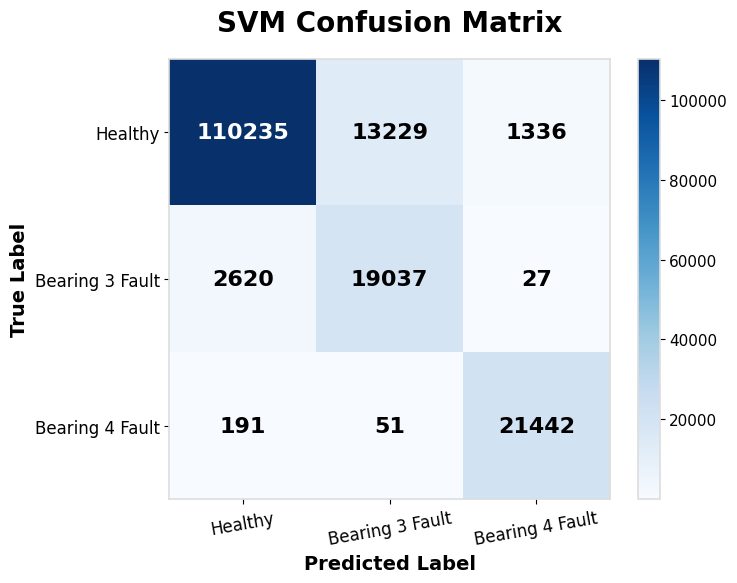

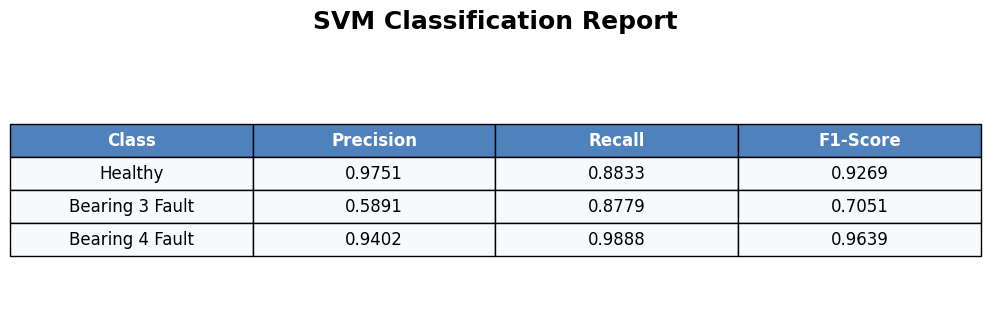


NAIVE BAYES RESULTS

Classification Report:

              precision    recall  f1-score   support

           0     0.9098    0.9330    0.9212    124800
           1     0.6707    0.1189    0.2020     21684
           2     0.4978    0.8342    0.6235     21684

    accuracy                         0.8153    168168
   macro avg     0.6927    0.6287    0.5823    168168
weighted avg     0.8258    0.8153    0.7901    168168


Accuracy: 0.8153


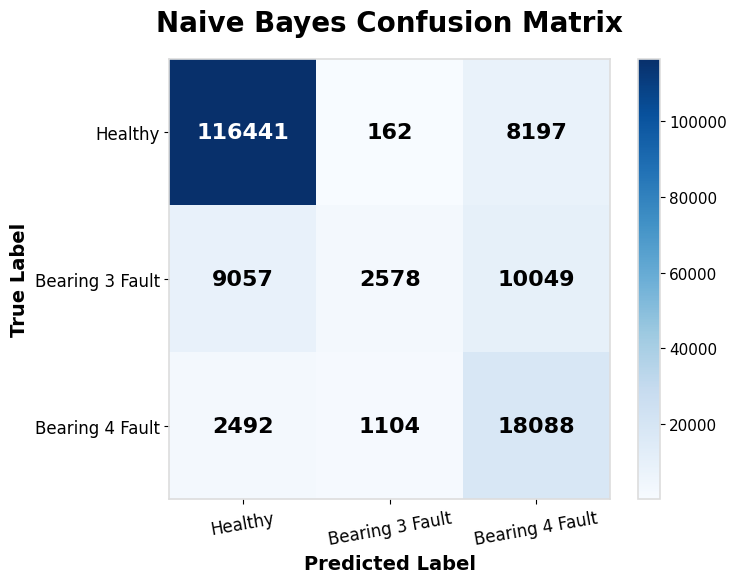

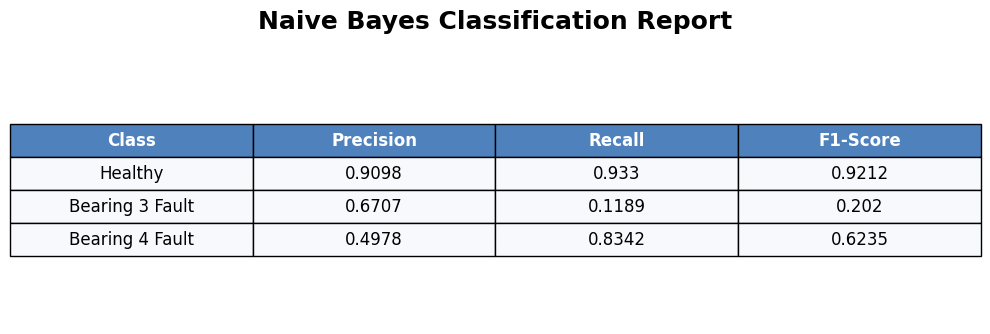

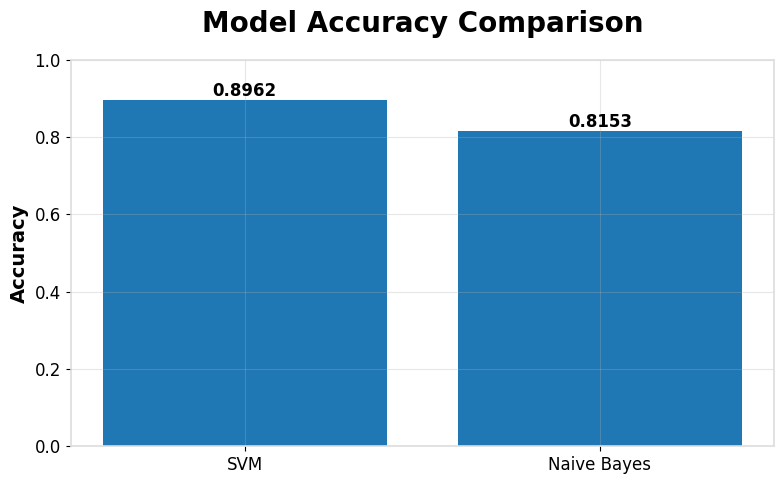


ALL PREMIUM VISUALS GENERATED SUCCESSFULLY

Saved Folder: svm_nb_visual_results
ZIP File: svm_nb_premium_results.zip


In [ ]:
# =========================================================
# PREMIUM SVM + NAIVE BAYES VISUALIZATION
# ===== LIGHT MODERN LINKEDIN STYLE =======================
# =========================================================

import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# =========================================================
# CLASS LABELS
# =========================================================

classes = [
    "Healthy",
    "Bearing 3 Fault",
    "Bearing 4 Fault"
]

# =========================================================
# MODELS
# =========================================================

models = {

    "SVM": (
        svm_true,
        svm_preds
    ),

    "Naive Bayes": (
        nb_true,
        nb_preds
    )
}

# =========================================================
# OUTPUT FOLDER
# =========================================================

output_dir = "svm_nb_visual_results"

os.makedirs(output_dir, exist_ok=True)

# =========================================================
# STYLE
# =========================================================

plt.rcParams.update({

    "figure.figsize": (7, 6),

    "font.size": 12,

    "axes.titlesize": 20,

    "axes.labelsize": 14
})

# =========================================================
# STORE ACCURACY
# =========================================================

accuracy_scores = []

# =========================================================
# LOOP THROUGH MODELS
# =========================================================

for model_name, (y_true, y_pred) in models.items():

    print("\n" + "="*70)

    print(f"{model_name.upper()} RESULTS")

    print("="*70)

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    report = classification_report(
        y_true,
        y_pred,
        digits=4
    )

    print("\nClassification Report:\n")

    print(report)

    # =====================================================
    # ACCURACY
    # =====================================================

    acc = accuracy_score(y_true, y_pred)

    accuracy_scores.append((model_name, acc))

    print(f"\nAccuracy: {acc:.4f}")

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7.5, 6))

    fig.patch.set_facecolor("white")

    ax.set_facecolor("white")

    im = ax.imshow(
        cm,
        cmap="Blues"
    )

    ax.set_title(
        f"{model_name} Confusion Matrix",
        fontsize=20,
        fontweight="bold",
        pad=20
    )

    ax.set_xlabel(
        "Predicted Label",
        fontweight="bold"
    )

    ax.set_ylabel(
        "True Label",
        fontweight="bold"
    )

    ax.set_xticks(np.arange(len(classes)))

    ax.set_yticks(np.arange(len(classes)))

    ax.set_xticklabels(
        classes,
        rotation=10
    )

    ax.set_yticklabels(classes)

    # =====================================================
    # AUTO TEXT COLOR
    # =====================================================

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            value = cm[i, j]

            text_color = (
                "white"
                if value > threshold
                else "black"
            )

            ax.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=text_color
            )

    # =====================================================
    # COLORBAR
    # =====================================================

    cbar = plt.colorbar(im)

    cbar.ax.tick_params(labelsize=11)

    plt.tight_layout()

    # SHOW

    plt.show()

    # SAVE MATRIX

    matrix_path = os.path.join(

        output_dir,

        model_name.lower()
        .replace(" ", "_")
        + "_confusion_matrix.png"
    )

    fig.savefig(
        matrix_path,
        dpi=400,
        bbox_inches="tight"
    )

    plt.close()

    # =====================================================
    # REPORT TABLE
    # =====================================================

    report_dict = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    rows = []

    for cls in ["0", "1", "2"]:

        rows.append([

            classes[int(cls)],

            round(report_dict[cls]["precision"], 4),

            round(report_dict[cls]["recall"], 4),

            round(report_dict[cls]["f1-score"], 4)
        ])

    df = pd.DataFrame(

        rows,

        columns=[
            "Class",
            "Precision",
            "Recall",
            "F1-Score"
        ]
    )

    fig, ax = plt.subplots(figsize=(10, 3.5))

    fig.patch.set_facecolor("white")

    ax.axis("off")

    table = ax.table(

        cellText=df.values,

        colLabels=df.columns,

        cellLoc="center",

        loc="center"
    )

    table.auto_set_font_size(False)

    table.set_fontsize(12)

    table.scale(1.2, 2)

    # =====================================================
    # TABLE STYLE
    # =====================================================

    for (row, col), cell in table.get_celld().items():

        if row == 0:

            cell.set_text_props(
                weight="bold",
                color="white"
            )

            cell.set_facecolor("#4F81BD")

        else:

            cell.set_facecolor("#F7F9FC")

    plt.title(
        f"{model_name} Classification Report",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()

    # SHOW

    plt.show()

    # SAVE REPORT

    report_path = os.path.join(

        output_dir,

        model_name.lower()
        .replace(" ", "_")
        + "_report.png"
    )

    fig.savefig(
        report_path,
        dpi=400,
        bbox_inches="tight"
    )

    plt.close()

# =========================================================
# ACCURACY COMPARISON
# =========================================================

model_names = [x[0] for x in accuracy_scores]

scores = [x[1] for x in accuracy_scores]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    model_names,
    scores
)

ax.set_ylim(0, 1)

ax.set_title(
    "Model Accuracy Comparison",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_ylabel(
    "Accuracy",
    fontweight="bold"
)

for bar, score in zip(bars, scores):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        score + 0.01,
        f"{score:.4f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

ax.grid(alpha=0.3)

plt.tight_layout()

# SHOW

plt.show()

# SAVE

comparison_path = os.path.join(
    output_dir,
    "accuracy_comparison.png"
)

fig.savefig(
    comparison_path,
    dpi=400,
    bbox_inches="tight"
)

plt.close()

# =========================================================
# ZIP EVERYTHING
# =========================================================

zip_filename = "svm_nb_premium_results.zip"

with zipfile.ZipFile(
    zip_filename,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(output_dir):

        for file in files:

            file_path = os.path.join(root, file)

            zipf.write(
                file_path,
                arcname=file
            )

print("\n" + "="*70)
print("ALL PREMIUM VISUALS GENERATED SUCCESSFULLY")
print("="*70)

print(f"\nSaved Folder: {output_dir}")

print(f"ZIP File: {zip_filename}")

In [ ]:
# ================= WINDOW-LEVEL IMS PIPELINE =================
# ===== LGBM FEATURE SELECTION -> XGBOOST + RF ===============
# ===== ENHANCED FEATURES ====================================

import os
import numpy as np
import pandas as pd

from scipy.signal import hilbert

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------

data_dir = "/content/mydata/IMS/1st_test"

window_size = 1024
stride = 512

HEALTHY_END = 1600

TOP_K = 13

# -------------------------------------------------------
# WINDOWING
# -------------------------------------------------------

def get_windows(signal):

    return np.lib.stride_tricks.sliding_window_view(
        signal,
        window_shape=(window_size, signal.shape[1])
    )[::stride, 0]

# -------------------------------------------------------
# FEATURE EXTRACTION
# -------------------------------------------------------

def extract_features(window):

    window = window.astype(np.float32)

    # ===================================================
    # BASIC FEATURES
    # ===================================================

    rms = np.sqrt(np.mean(window ** 2, axis=0))

    std = np.std(window, axis=0)

    peak = np.max(np.abs(window), axis=0)

    pr = peak / (rms + 1e-8)

    mean = np.mean(window, axis=0)

    # ===================================================
    # TREND FEATURES
    # ===================================================

    t = np.arange(window.shape[0], dtype=np.float32)

    slopes = []

    for c in range(window.shape[1]):

        y = window[:, c]

        slope = np.sum((t - t.mean()) * (y - y.mean())) / (
            np.sum((t - t.mean())**2) + 1e-8
        )

        slopes.append(slope)

    # ===================================================
    # ROUGHNESS / DAMAGE
    # ===================================================

    roughness = np.mean(np.diff(window, axis=0) ** 2)

    damage = np.sum(np.abs(np.diff(window.mean(axis=1))))

    # ===================================================
    # FFT FEATURES
    # ===================================================

    fft = np.abs(np.fft.rfft(window, axis=0))

    hf_energy = (
        np.sum(fft[20:], axis=0).mean()
        / (np.sum(fft) + 1e-8)
    )

    # spectral entropy

    p = fft / (
        np.sum(fft, axis=0, keepdims=True) + 1e-8
    )

    spectral_entropy = -np.mean(
        np.sum(p * np.log(p + 1e-8), axis=0)
    )

    # ===================================================
    # ENVELOPE FEATURES
    # ===================================================

    env = np.abs(hilbert(window, axis=0))

    env_energy = np.mean(env ** 2)

    # ===================================================
    # IMPULSIVE FEATURES
    # ===================================================

    crest = np.mean(peak / (std + 1e-8))

    kurtosis = np.mean(
        np.mean((window - mean) ** 4, axis=0)
        / (std ** 4 + 1e-8)
    )

    skewness = np.mean(
        np.mean((window - mean) ** 3, axis=0)
        / (std ** 3 + 1e-8)
    )

    # ===================================================
    # FINAL FEATURE VECTOR
    # ===================================================

    return np.concatenate([

        rms,
        std,
        peak,
        pr,

        np.array(slopes),

        np.array([
            damage,
            roughness,
            hf_energy,
            env_energy,
            crest,
            kurtosis,
            skewness,
            spectral_entropy
        ])

    ])

# -------------------------------------------------------
# BUILD DATASET
# -------------------------------------------------------

files = sorted(os.listdir(data_dir))

X = []
y = []
groups = []

for i, file_name in enumerate(files):

    path = os.path.join(data_dir, file_name)

    signal = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        usecols=[4, 5, 6, 7]
    ).values.astype(np.float32)

    # bearing groups

    B3 = signal[:, 0:2]
    B4 = signal[:, 2:4]

    w3 = get_windows(B3)
    w4 = get_windows(B4)

    if len(w3) == 0 or len(w4) == 0:
        continue

    label_b3 = 0 if i < HEALTHY_END else 1
    label_b4 = 0 if i < HEALTHY_END else 2

    # ---------------- B3 ----------------

    for w in w3:

        X.append(extract_features(w))
        y.append(label_b3)
        groups.append(i)

    # ---------------- B4 ----------------

    for w in w4:

        X.append(extract_features(w))
        y.append(label_b4)
        groups.append(i)

    if i % 200 == 0:
        print(f"Processed {i}/{len(files)} files")

# -------------------------------------------------------
# FINAL DATA
# -------------------------------------------------------

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

print("\nFeature Shape:", X.shape)

print(
    "Class Distribution:",
    np.unique(y, return_counts=True)
)

# -------------------------------------------------------
# GROUP KFOLD
# -------------------------------------------------------

gkf = GroupKFold(n_splits=5)

# =======================================================
# XGBOOST RESULTS
# =======================================================

xgb_preds = []
xgb_true = []

# =======================================================
# RANDOM FOREST RESULTS
# =======================================================

rf_preds = []
rf_true = []

# -------------------------------------------------------
# CROSS VALIDATION
# -------------------------------------------------------

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups)
):

    print(f"\n========== Fold {fold+1} ==========")

    X_train, X_test = X[train_idx], X[test_idx]

    y_train, y_test = y[train_idx], y[test_idx]

    # ===================================================
    # SCALING
    # ===================================================

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)

    X_test = scaler.transform(X_test)

    # ===================================================
    # LIGHTGBM FEATURE SELECTION
    # ===================================================

    selector_model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.08,
        num_leaves=31,
        class_weight={0:1, 1:3, 2:1},
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    selector_model.fit(X_train, y_train)

    importances = selector_model.feature_importances_

    top_idx = np.argsort(importances)[-TOP_K:]

    print("Selected Features:", top_idx)

    X_train_sel = X_train[:, top_idx]

    X_test_sel = X_test[:, top_idx]

    # ===================================================
    # XGBOOST
    # ===================================================

    xgb_model = XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=3,
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )

    xgb_model.fit(X_train_sel, y_train)

    xgb_pred = xgb_model.predict(X_test_sel)

    xgb_preds.extend(xgb_pred)

    xgb_true.extend(y_test)

    # ===================================================
    # RANDOM FOREST
    # ===================================================

    rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    rf_model.fit(X_train_sel, y_train)

    rf_pred = rf_model.predict(X_test_sel)

    rf_preds.extend(rf_pred)

    rf_true.extend(y_test)

    print("Fold Completed")

# -------------------------------------------------------
# FINAL RESULTS
# -------------------------------------------------------

print("\n================ XGBOOST RESULT ================")

print(
    classification_report(
        xgb_true,
        xgb_preds,
        digits=4
    )
)

print("\n================ RANDOM FOREST RESULT ================")

print(
    classification_report(
        rf_true,
        rf_preds,
        digits=4
    )
)

Processed 0/2156 files
Processed 200/2156 files
Processed 400/2156 files
Processed 600/2156 files
Processed 800/2156 files
Processed 1000/2156 files
Processed 1200/2156 files
Processed 1400/2156 files
Processed 1600/2156 files
Processed 1800/2156 files
Processed 2000/2156 files

Feature Shape: (168168, 18)
Class Distribution: (array([0, 1, 2]), array([124800,  21684,  21684]))

========== Fold 1 ==========
Selected Features: [ 0 16  5 14  1 15 12 13  2 17 10 11  3]
Fold Completed

========== Fold 2 ==========
Selected Features: [ 4  0 16 14  1 15 13 12 17  2 10  3 11]
Fold Completed

========== Fold 3 ==========
Selected Features: [ 5 14 16  0  1 13 15 12  2 17 10  3 11]
Fold Completed

========== Fold 4 ==========
Selected Features: [ 0  4  1 16 14 15 12 13  2 17 10  3 11]
Fold Completed

========== Fold 5 ==========
Selected Features: [ 0  4 14 16  1 15 13 12 17  2 10 11  3]
Fold Completed

================ XGBOOST RESULT ================
              precision    recall  f1-score  

In [ ]:
# ==========================================================
# VISUAL RESULT GENERATION
# ===== XGBOOST + RANDOM FOREST ============================
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# ----------------------------------------------------------
# CONFUSION MATRIX
# ----------------------------------------------------------

def save_conf_matrix(y_true, y_pred, title, filename):

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(cm)

    ax.set_title(title, fontsize=14)

    ax.set_xlabel("Predicted Label", fontsize=12)

    ax.set_ylabel("True Label", fontsize=12)

    classes = np.unique(y_true)

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))

    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)

    # numbers inside matrix

    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=12
            )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# ----------------------------------------------------------
# CLASSIFICATION REPORT IMAGE
# ----------------------------------------------------------

def save_report(y_true, y_pred, title, filename):

    report = classification_report(
        y_true,
        y_pred,
        digits=4
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.axis("off")

    ax.set_title(
        title,
        fontsize=14
    )

    ax.text(
        0,
        1,
        report,
        va="top",
        family="monospace",
        fontsize=11
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# ==========================================================
# XGBOOST RESULTS
# ==========================================================

save_conf_matrix(
    xgb_true,
    xgb_preds,
    "XGBoost Confusion Matrix",
    "xgboost_confusion_matrix.png"
)

save_report(
    xgb_true,
    xgb_preds,
    "XGBoost Classification Report",
    "xgboost_classification_report.png"
)

# ==========================================================
# RANDOM FOREST RESULTS
# ==========================================================

save_conf_matrix(
    rf_true,
    rf_preds,
    "Random Forest Confusion Matrix",
    "rf_confusion_matrix.png"
)

save_report(
    rf_true,
    rf_preds,
    "Random Forest Classification Report",
    "rf_classification_report.png"
)

print("\nSaved all visualization images successfully.")


Saved all visualization images successfully.



XGBOOST RESULTS

Classification Report:

              precision    recall  f1-score   support

           0     0.9416    0.9830    0.9619    124800
           1     0.8886    0.6788    0.7697     21684
           2     0.9841    0.9674    0.9757     21684

    accuracy                         0.9418    168168
   macro avg     0.9381    0.8764    0.9024    168168
weighted avg     0.9403    0.9418    0.9389    168168


Accuracy: 0.9418


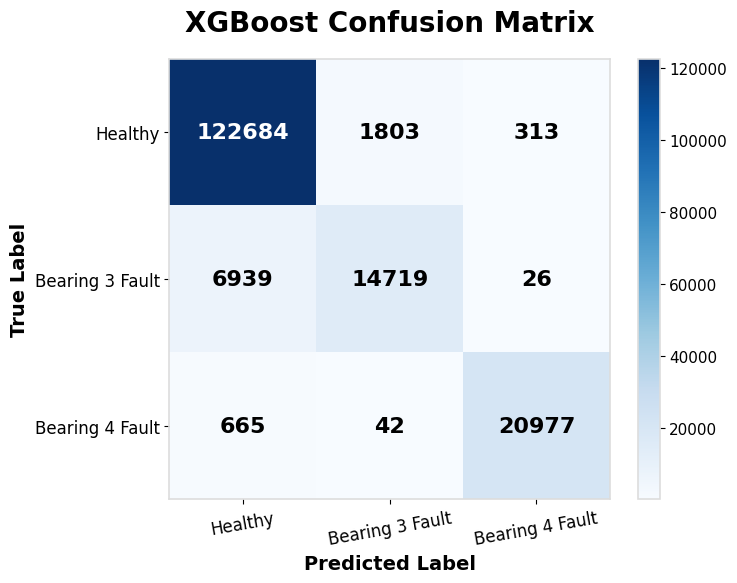

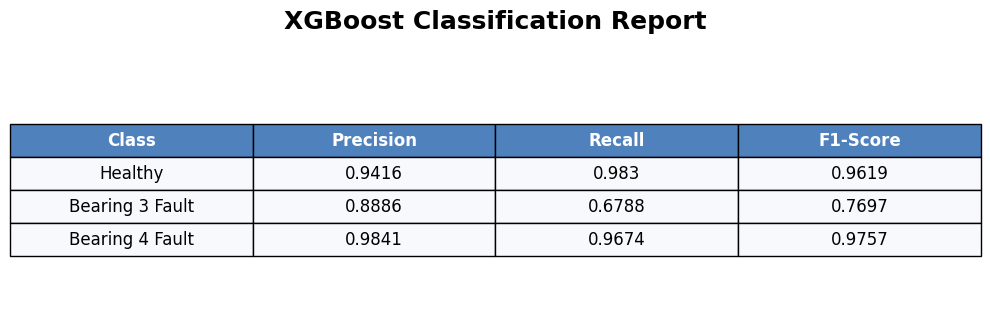


RANDOM FOREST RESULTS

Classification Report:

              precision    recall  f1-score   support

           0     0.9344    0.9857    0.9594    124800
           1     0.8998    0.6354    0.7449     21684
           2     0.9852    0.9636    0.9743     21684

    accuracy                         0.9377    168168
   macro avg     0.9398    0.8616    0.8928    168168
weighted avg     0.9365    0.9377    0.9336    168168


Accuracy: 0.9377


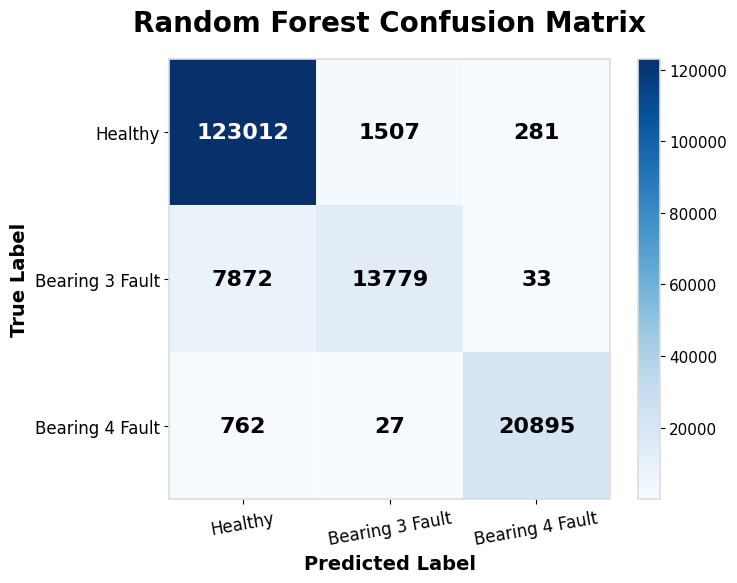

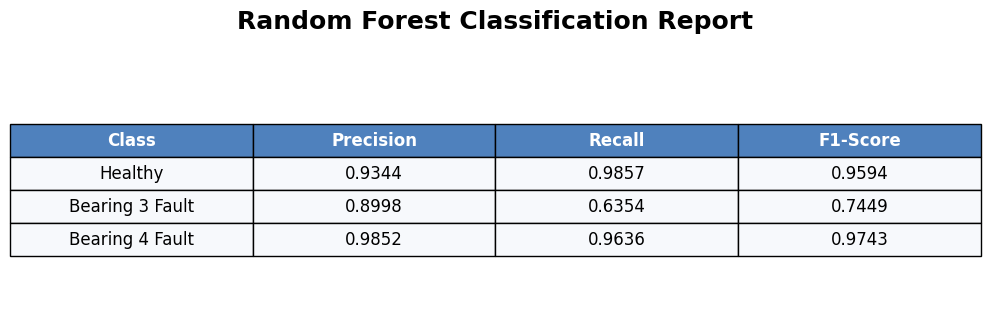

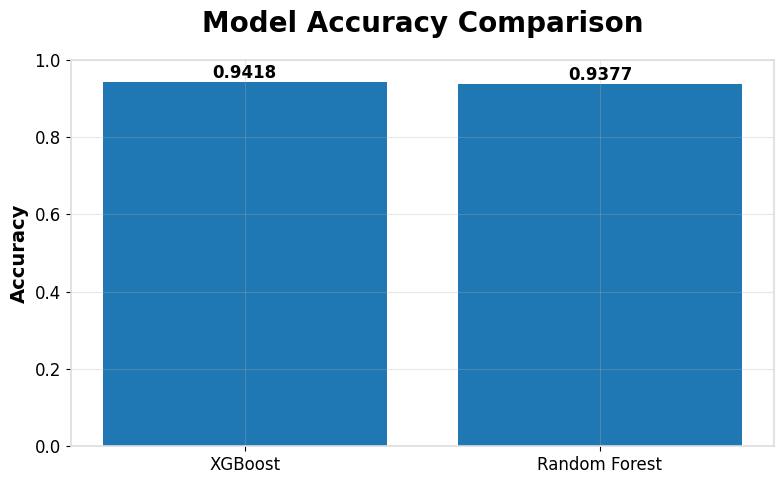


ALL PREMIUM VISUALS GENERATED SUCCESSFULLY

Saved Folder: premium_results
ZIP File: premium_visual_results.zip


In [ ]:
# =========================================================
# PREMIUM ALL-MODEL RESULT VISUALIZATION
# ===== LIGHT THEME + AUTO TEXT COLOR + REPORTS ===========
# =========================================================

import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# =========================================================
# CLASS LABELS
# =========================================================

classes = [
    "Healthy",
    "Bearing 3 Fault",
    "Bearing 4 Fault"
]

# =========================================================
# MODEL DICTIONARY
# =========================================================

models = {

    "XGBoost": (
        xgb_true,
        xgb_preds
    ),

    "Random Forest": (
        rf_true,
        rf_preds
    ),

    # Uncomment if available

    # "SVM": (
    #     svm_true,
    #     svm_preds
    # ),

    # "Naive Bayes": (
    #     nb_true,
    #     nb_preds
    # )
}

# =========================================================
# OUTPUT FOLDER
# =========================================================

output_dir = "premium_results"

os.makedirs(output_dir, exist_ok=True)

# =========================================================
# STYLE
# =========================================================

plt.rcParams.update({

    "figure.figsize": (7, 6),

    "font.size": 12,

    "axes.titlesize": 20,

    "axes.labelsize": 14
})

# =========================================================
# STORE ACCURACY
# =========================================================

accuracy_scores = []

# =========================================================
# LOOP THROUGH MODELS
# =========================================================

for model_name, (y_true, y_pred) in models.items():

    print("\n" + "="*70)

    print(f"{model_name.upper()} RESULTS")

    print("="*70)

    # =====================================================
    # CLASSIFICATION REPORT IN CONSOLE
    # =====================================================

    report = classification_report(
        y_true,
        y_pred,
        digits=4
    )

    print("\nClassification Report:\n")

    print(report)

    # =====================================================
    # ACCURACY
    # =====================================================

    acc = accuracy_score(y_true, y_pred)

    accuracy_scores.append((model_name, acc))

    print(f"\nAccuracy: {acc:.4f}")

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7.5, 6))

    fig.patch.set_facecolor("white")

    ax.set_facecolor("white")

    im = ax.imshow(
        cm,
        cmap="Blues"
    )

    ax.set_title(
        f"{model_name} Confusion Matrix",
        fontsize=20,
        fontweight="bold",
        pad=20
    )

    ax.set_xlabel(
        "Predicted Label",
        fontweight="bold"
    )

    ax.set_ylabel(
        "True Label",
        fontweight="bold"
    )

    ax.set_xticks(np.arange(len(classes)))

    ax.set_yticks(np.arange(len(classes)))

    ax.set_xticklabels(
        classes,
        rotation=10
    )

    ax.set_yticklabels(classes)

    # =====================================================
    # AUTO TEXT COLOR
    # =====================================================

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            value = cm[i, j]

            text_color = (
                "white"
                if value > threshold
                else "black"
            )

            ax.text(
                j,
                i,
                str(value),
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=text_color
            )

    # =====================================================
    # COLORBAR
    # =====================================================

    cbar = plt.colorbar(im)

    cbar.ax.tick_params(labelsize=11)

    plt.tight_layout()

    # =====================================================
    # SHOW MATRIX
    # =====================================================

    plt.show()

    # =====================================================
    # SAVE MATRIX
    # =====================================================

    matrix_path = os.path.join(

        output_dir,

        model_name.lower()
        .replace(" ", "_")
        + "_confusion_matrix.png"
    )

    fig.savefig(
        matrix_path,
        dpi=400,
        bbox_inches="tight"
    )

    plt.close()

    # =====================================================
    # REPORT TABLE
    # =====================================================

    report_dict = classification_report(
        y_true,
        y_pred,
        output_dict=True
    )

    rows = []

    for cls in ["0", "1", "2"]:

        rows.append([

            classes[int(cls)],

            round(report_dict[cls]["precision"], 4),

            round(report_dict[cls]["recall"], 4),

            round(report_dict[cls]["f1-score"], 4)
        ])

    df = pd.DataFrame(

        rows,

        columns=[
            "Class",
            "Precision",
            "Recall",
            "F1-Score"
        ]
    )

    fig, ax = plt.subplots(figsize=(10, 3.5))

    fig.patch.set_facecolor("white")

    ax.axis("off")

    table = ax.table(

        cellText=df.values,

        colLabels=df.columns,

        cellLoc="center",

        loc="center"
    )

    table.auto_set_font_size(False)

    table.set_fontsize(12)

    table.scale(1.2, 2)

    # =====================================================
    # TABLE STYLE
    # =====================================================

    for (row, col), cell in table.get_celld().items():

        if row == 0:

            cell.set_text_props(
                weight="bold",
                color="white"
            )

            cell.set_facecolor("#4F81BD")

        else:

            cell.set_facecolor("#F7F9FC")

    plt.title(
        f"{model_name} Classification Report",
        fontsize=18,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()

    # =====================================================
    # SHOW REPORT
    # =====================================================

    plt.show()

    # =====================================================
    # SAVE REPORT
    # =====================================================

    report_path = os.path.join(

        output_dir,

        model_name.lower()
        .replace(" ", "_")
        + "_report.png"
    )

    fig.savefig(
        report_path,
        dpi=400,
        bbox_inches="tight"
    )

    plt.close()

# =========================================================
# ACCURACY COMPARISON CHART
# =========================================================

model_names = [x[0] for x in accuracy_scores]

scores = [x[1] for x in accuracy_scores]

fig, ax = plt.subplots(figsize=(8, 5))

fig.patch.set_facecolor("white")

bars = ax.bar(
    model_names,
    scores
)

ax.set_ylim(0, 1)

ax.set_title(
    "Model Accuracy Comparison",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_ylabel(
    "Accuracy",
    fontweight="bold"
)

# values

for bar, score in zip(bars, scores):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        score + 0.01,
        f"{score:.4f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

ax.grid(alpha=0.3)

plt.tight_layout()

# SHOW

plt.show()

# SAVE

comparison_path = os.path.join(
    output_dir,
    "accuracy_comparison.png"
)

fig.savefig(
    comparison_path,
    dpi=400,
    bbox_inches="tight"
)

plt.close()

# =========================================================
# ZIP EVERYTHING
# =========================================================

zip_filename = "premium_visual_results.zip"

with zipfile.ZipFile(
    zip_filename,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(output_dir):

        for file in files:

            file_path = os.path.join(root, file)

            zipf.write(
                file_path,
                arcname=file
            )

print("\n" + "="*70)
print("ALL PREMIUM VISUALS GENERATED SUCCESSFULLY")
print("="*70)

print(f"\nSaved Folder: {output_dir}")

print(f"ZIP File: {zip_filename}")


=========== TOP IMPORTANT FEATURES ===========

             Feature  Importance
11         roughness        1745
3            std_ch2        1661
10            damage        1444
17  spectral_entropy        1165
2            std_ch1        1111
12         hf_energy         867
15          kurtosis         833
13        env_energy         810
1            rms_ch2         473
16          skewness         471
14      crest_factor         417
4           peak_ch1         396
0            rms_ch1         385
5           peak_ch2         380
8          slope_ch1         373


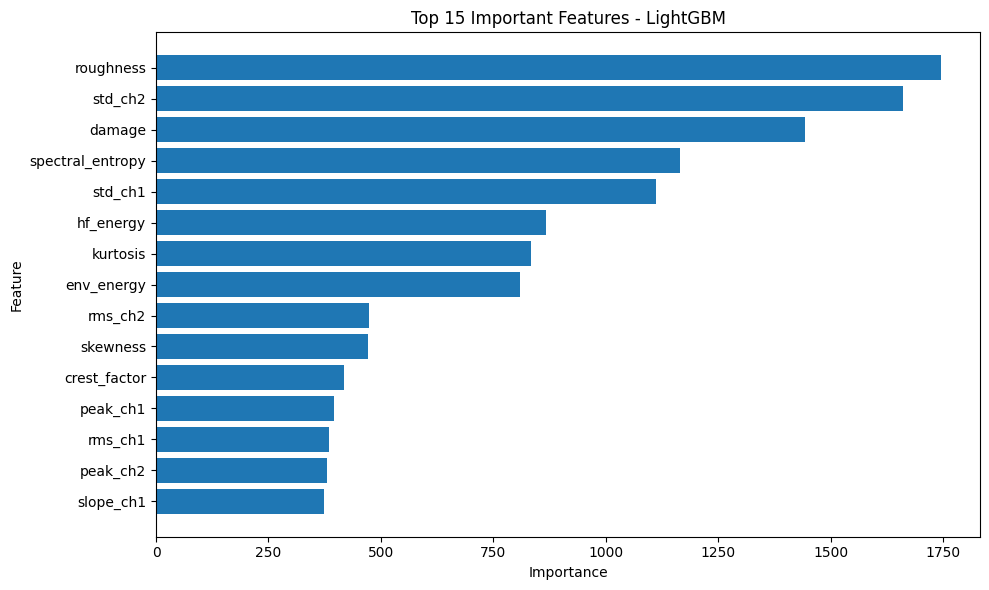

In [ ]:
# =======================================================
# GLOBAL FEATURE IMPORTANCE ANALYSIS
# =======================================================

import matplotlib.pyplot as plt

# feature names
feature_names = []

channels = ["ch1", "ch2"]

# basic features
for f in ["rms", "std", "peak", "peak_ratio"]:
    for ch in channels:
        feature_names.append(f"{f}_{ch}")

# slope features
for ch in channels:
    feature_names.append(f"slope_{ch}")

# global engineered features
feature_names += [
    "damage",
    "roughness",
    "hf_energy",
    "env_energy",
    "crest_factor",
    "kurtosis",
    "skewness",
    "spectral_entropy"
]

# =======================================================
# TRAIN LIGHTGBM ON FULL DATA
# =======================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

lgbm_model = LGBMClassifier(
    n_estimators=150,
    learning_rate=0.08,
    num_leaves=31,
    class_weight={0:1, 1:3, 2:1},
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(X_scaled, y)

# =======================================================
# FEATURE IMPORTANCE
# =======================================================

importances = lgbm_model.feature_importances_

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

# =======================================================
# PRINT TOP FEATURES
# =======================================================

print("\n=========== TOP IMPORTANT FEATURES ===========\n")

print(feature_df.head(15))

# =======================================================
# PLOT
# =======================================================

plt.figure(figsize=(10,6))

plt.barh(
    feature_df["Feature"][:15][::-1],
    feature_df["Importance"][:15][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features - LightGBM")

plt.tight_layout()
plt.show()